In [ ]:
from google.colab import files
uploaded = files.upload()

Saving PhonePe_Transaction_Statement.csv to PhonePe_Transaction_Statement.csv


In [ ]:
import pandas as pd

filename = list(uploaded.keys())[0]

with open(filename, 'r') as f:
    lines = f.readlines()

header_row = 0
for i, line in enumerate(lines):
    if line.strip().startswith('Date,'):
        header_row = i
        break

df = pd.read_csv(filename, skiprows=header_row)
df.columns = df.columns.str.strip()

def categorize(row):
    text = str(row['Transaction Details']).lower()
    if row['Transaction Type'] == 'Credit':
        return 'Income'
    if 'recharge' in text:
        return 'Recharge/Bills'
    if any(k in text for k in ['medical','clinic','pharma']):
        return 'Medical'
    if any(k in text for k in ['petroleum','pay & park','transport commissioner']):
        return 'Travel/Fuel'
    if any(k in text for k in ['ice cream','sweet','tea','chicken','pizza','food','farsan','bhel','fast food','vada pav','samosa','shawarma','rolls','hotel','amruttulya','mithai']):
        return 'Food'
    if any(k in text for k in ['kirana','general','super market','traders','provision','grocery','enterprises','stores','store']):
        return 'Groceries'
    if any(k in text for k in ['stationery','xerox']):
        return 'Stationery'
    if any(k in text for k in ['university','institute','education','school']):
        return 'Education'
    if any(k in text for k in ['parlour','parlor','hair','beauty','nails']):
        return 'Personal Care'
    if any(k in text for k in ['amazon','flipkart']):
        return 'Shopping'
    if 'paid to' in text:
        return 'Personal Transfer'
    return 'Other'

df['Category'] = df.apply(categorize, axis=1)
print(df['Category'].value_counts())
df.to_csv('categorized_expenses.csv', index=False)

Category
Personal Transfer    285
Income               178
Food                  68
Groceries             59
Recharge/Bills        35
Personal Care         28
Medical               23
Travel/Fuel           19
Stationery             7
Education              6
Shopping               4
Name: count, dtype: int64


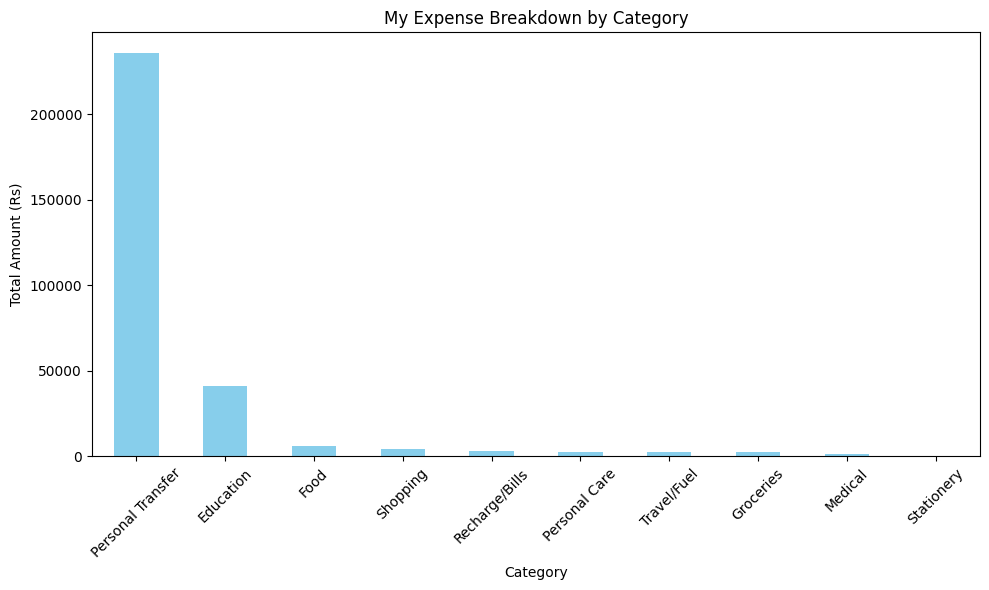

In [ ]:
import matplotlib.pyplot as plt

spend = df[df['Transaction Type']=='Debit'].groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
spend.plot(kind='bar', color='skyblue')
plt.title('My Expense Breakdown by Category')
plt.ylabel('Total Amount (Rs)')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('expense_chart.png')
plt.show()